In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp

#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

colors = ["#FF3E3E","#FF964F","#1982C4","black"]



In [2]:
def compute_IBs_and_errors(imbs_X_to_Y, imbs_Y_to_X, correction=True, confidence=0.999):
    '''imbs_X_to_Y and imbs_Y_to_X have shape (n_seeds, n_taus, n_alphas)
    '''

    assert imbs_X_to_Y.shape == imbs_Y_to_X.shape, "Error: shapes of two inputs do not match!"
    n_indep_realizations = imbs_X_to_Y.shape[0]
    n_taus = imbs_X_to_Y.shape[1]
    
    # compute average IGs as a function of tau and alpha
    IB_X_to_Y_avg = imbs_X_to_Y.mean(axis=0)
    IB_Y_to_X_avg = imbs_Y_to_X.mean(axis=0)        

    # extract global alpha minimized for each tau
    alphas_min_X_to_Y = np.argmin(IB_X_to_Y_avg, axis=-1)
    alphas_min_Y_to_X = np.argmin(IB_Y_to_X_avg, axis=-1)

    # compute IGs as a function of tau
    IBG_Y0X0_to_Y_avg = IB_X_to_Y_avg[np.arange(n_taus),alphas_min_X_to_Y]
    IBG_X0Y0_to_X_avg = IB_Y_to_X_avg[np.arange(n_taus),alphas_min_Y_to_X]

    IB_Y0_to_Y_avg =  IB_X_to_Y_avg[:,0]
    IB_X0_to_X_avg =  IB_Y_to_X_avg[:,0]

    assert IB_Y0_to_Y_avg.shape == IBG_Y0X0_to_Y_avg.shape, "Error: shapes of two outputs do not match!"
    
    return (IB_Y0_to_Y_avg, IB_X0_to_X_avg, 
            IBG_Y0X0_to_Y_avg, IBG_X0Y0_to_X_avg, 
            alphas_min_X_to_Y, alphas_min_Y_to_X)

In [3]:
def compute_gains_and_errors(imbs_X_to_Y, imbs_Y_to_X, correction=True, confidence=0.999):
    '''imbs_X_to_Y and imbs_Y_to_X have shape (n_seeds, n_taus, n_alphas)
    '''

    assert imbs_X_to_Y.shape == imbs_Y_to_X.shape, "Error: shapes of two inputs do not match!"
    n_indep_realizations = imbs_X_to_Y.shape[0]
    n_taus = imbs_X_to_Y.shape[1]
    
    # compute IGs as a function of tau and alpha
    gain_X_to_Y_indep = 100*(imbs_X_to_Y[:,:,0,np.newaxis]-imbs_X_to_Y[:,:,:]) \
      / imbs_X_to_Y[:,:,0,np.newaxis]
    gain_Y_to_X_indep = 100*(imbs_Y_to_X[:,:,0,np.newaxis]-imbs_Y_to_X[:,:,:]) \
      / imbs_Y_to_X[:,:,0,np.newaxis]

    # compute average IGs as a function of tau and alpha
    gain_X_to_Y_avg = gain_X_to_Y_indep.mean(axis=0)
    gain_Y_to_X_avg = gain_Y_to_X_indep.mean(axis=0)        

    # extract global alpha minimized for each tau
    alphas_max_X_to_Y = np.argmax(gain_X_to_Y_avg, axis=-1)
    alphas_max_Y_to_X = np.argmax(gain_Y_to_X_avg, axis=-1)

    # compute IGs as a function of tau
    gain_X_to_Y_avg = gain_X_to_Y_avg[np.arange(n_taus),alphas_max_X_to_Y]
    gain_Y_to_X_avg = gain_Y_to_X_avg[np.arange(n_taus),alphas_max_Y_to_X] 

    # compute errors associated to IGs as a function of tau (standard error of the mean)
    error_X_to_Y = gain_X_to_Y_indep.std(axis=0)[np.arange(n_taus),alphas_max_X_to_Y] \
     / np.sqrt(n_indep_realizations)
    error_Y_to_X = gain_Y_to_X_indep.std(axis=0)[np.arange(n_taus),alphas_max_Y_to_X] \
                    / np.sqrt(n_indep_realizations)

    # test statistical confidence according to one-tail t-test
    ttest_X_to_Y = ttest_onesamp(
        gain_X_to_Y_indep[:,np.arange(n_taus),alphas_max_X_to_Y], popmean=0, axis=0, alternative='greater'
    )
    ttest_Y_to_X = ttest_onesamp(
        gain_Y_to_X_indep[:,np.arange(n_taus),alphas_max_Y_to_X], popmean=0, axis=0, alternative='greater'
    )
    mask_X_to_Y = (ttest_X_to_Y.pvalue.data < 1. - confidence)
    mask_Y_to_X = (ttest_Y_to_X.pvalue.data < 1. - confidence)

    print("Check ttest ")
    
    # correction (set to 0 those IGs for which Imbalance(alpha=0) > 1)
    if correction:
        imb_X_to_Y_avg_alpha0 = imbs_X_to_Y.mean(axis=0)[:,0]
        taus_correction_X_to_Y = np.where(imb_X_to_Y_avg_alpha0 > 1.)
        gain_X_to_Y_avg[taus_correction_X_to_Y] = 0.
        error_X_to_Y[taus_correction_X_to_Y] = 0.
        mask_X_to_Y[taus_correction_X_to_Y] = False
        
        imb_Y_to_X_avg_alpha0 = imbs_Y_to_X.mean(axis=0)[:,0]
        taus_correction_Y_to_X = np.where(imb_Y_to_X_avg_alpha0 > 1.)
        gain_Y_to_X_avg[taus_correction_Y_to_X] = 0.
        error_Y_to_X[taus_correction_Y_to_X] = 0.
        mask_Y_to_X[taus_correction_Y_to_X] = False

    return (gain_X_to_Y_avg, gain_Y_to_X_avg, 
            error_X_to_Y, error_Y_to_X, 
            alphas_max_X_to_Y, alphas_max_Y_to_X,
            mask_X_to_Y, mask_Y_to_X)

In [4]:
colors = ["#FF3E3E","#FF964F","#1982C4","black"]


scale = 1.8
plt.rcParams.update({
    'font.size': 12 * scale,
    'axes.titlesize': 12 * scale,
    'axes.labelsize': 12 * scale,
    'xtick.labelsize': 10 * scale,
    'ytick.labelsize': 10 * scale,
    'legend.fontsize': 10 * scale,
})

k = 20
taus = np.arange(0,297)*10
seeds = np.arange(1,50+1)
E = 10
tau_e = 1
dci= 0

figsize = (6,4)

### ref dipole vs 1st shell

In [5]:
# read files dipole <-> environment, forward time
k = 20
taus = np.arange(0,495)
seeds = np.arange(1,50+1)
alphasize = 200
E = 5
tau_e = 1
dci = 0

info_imbalances_center_to_1st = np.zeros((len(seeds),len(taus),200))
info_imbalances_1st_to_center = np.zeros((len(seeds),len(taus),200))
info_imbalances_1st_to_2nd = np.zeros((len(seeds),len(taus),200))
info_imbalances_2nd_to_1st = np.zeros((len(seeds),len(taus),200))
info_imbalances_center_to_2nd = np.zeros((len(seeds),len(taus),200))
info_imbalances_2nd_to_center = np.zeros((len(seeds),len(taus),200))

info_imbalances_centerd_to_1std = np.zeros((len(seeds),len(taus),200))
info_imbalances_1std_to_centerd = np.zeros((len(seeds),len(taus),200))
info_imbalances_1std_to_2ndd = np.zeros((len(seeds),len(taus),200))
info_imbalances_2ndd_to_1std = np.zeros((len(seeds),len(taus),200))
info_imbalances_centerd_to_2ndd = np.zeros((len(seeds),len(taus),200))
info_imbalances_2ndd_to_centerd = np.zeros((len(seeds),len(taus),200))

info_imbalances_centerd_to_centerdipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_centerdipole_to_centerd = np.zeros((len(seeds),len(taus),200))
info_imbalances_centerd_to_1stdipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_1stdipole_to_centerd = np.zeros((len(seeds),len(taus),200))
info_imbalances_centerd_to_2nddipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_2nddipole_to_centerd = np.zeros((len(seeds),len(taus),200))

info_imbalances_1std_to_centerdipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_centerdipole_to_1std = np.zeros((len(seeds),len(taus),200))
info_imbalances_1std_to_1stdipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_1stdipole_to_1std = np.zeros((len(seeds),len(taus),200))
info_imbalances_1std_to_2nddipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_2nddipole_to_1std = np.zeros((len(seeds),len(taus),200))

info_imbalances_2ndd_to_centerdipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_centerdipole_to_2ndd = np.zeros((len(seeds),len(taus),200))
info_imbalances_2ndd_to_1stdipole = np.zeros((len(seeds),len(taus),200))
info_imbalances_1stdipole_to_2ndd = np.zeros((len(seeds),len(taus),200))
info_imbalances_2ndd_to_2nddipole  = np.zeros((len(seeds),len(taus),200))
info_imbalances_2nddipole_to_2ndd = np.zeros((len(seeds),len(taus),200))

for i, seed in enumerate(seeds):
    for j, tau in enumerate(taus):

        (info_imbalances_center_to_1st[i,j], info_imbalances_1st_to_center[i,j],
        info_imbalances_1st_to_2nd[i,j], info_imbalances_2nd_to_1st[i,j],
        info_imbalances_center_to_2nd[i,j], info_imbalances_2nd_to_center[i,j],

        info_imbalances_centerd_to_1std[i,j], info_imbalances_1std_to_centerd[i,j],
        info_imbalances_1std_to_2ndd[i,j],    info_imbalances_2ndd_to_1std[i,j],
        info_imbalances_centerd_to_2ndd[i,j], info_imbalances_2ndd_to_centerd[i,j],

        info_imbalances_centerd_to_centerdipole[i,j], info_imbalances_centerdipole_to_centerd[i,j],
        info_imbalances_centerd_to_1stdipole[i,j], info_imbalances_1stdipole_to_centerd[i,j],
        info_imbalances_centerd_to_2nddipole[i,j], info_imbalances_2nddipole_to_centerd[i,j],

        info_imbalances_1std_to_centerdipole[i,j], info_imbalances_centerdipole_to_1std[i,j],
        info_imbalances_1std_to_1stdipole[i,j], info_imbalances_1stdipole_to_1std[i,j],
        info_imbalances_1std_to_2nddipole[i,j], info_imbalances_2nddipole_to_1std[i,j],

        info_imbalances_2ndd_to_centerdipole[i,j], info_imbalances_centerdipole_to_2ndd[i,j],
        info_imbalances_2ndd_to_1stdipole[i,j], info_imbalances_1stdipole_to_2ndd[i,j],
        info_imbalances_2ndd_to_2nddipole[i,j], info_imbalances_2nddipole_to_2ndd[i,j],

        ) = (
            pickle.load(open(f"pickles_imb/imb_seed{seed}_E{E}_tau{tau}_k{k}.p","rb"))
        )

In [6]:
def make_plot(
        info_imbalances_X_to_Y, info_imbalances_Y_to_X,
        label_IG_X_to_Y, label_IG_Y_to_X, label_IB_Y0_to_Y, label_IB_Y0X0_Y, label_IB_X0_to_X, label_IB_X0Y0_X,
        xlim = 20,
        ylim = 0.5,
        nseed = 50,
        name_tpl = '',
        label = ''
):

    #final_time = 30 # in ns
    final_time_index = len(info_imbalances_X_to_Y[0,:])
    taus_plot = taus[:final_time_index]
    time_Emb_tau = 0.1
    taus_plot_factor = 0.1


    # compute mean IBS and error
    (IB_Y0_to_Y_avg, IB_X0_to_X_avg, 
            IBG_Y0X0_to_Y_avg, IBG_X0Y0_to_X_avg, 
            alphas_min_X_to_Y, alphas_min_Y_to_X) = (
                compute_IBs_and_errors(info_imbalances_X_to_Y[:,:final_time_index], 
                                         info_imbalances_Y_to_X[:,:final_time_index])
            )

    # compute IGs, errors, and confidence masks
    (gain_X_to_Y_avg, gain_Y_to_X_avg, error_X_to_Y, error_Y_to_X, 
     alphas_X_to_Y, alphas_Y_to_X,mask_X_to_Y, mask_Y_to_X) = (
                compute_gains_and_errors(info_imbalances_X_to_Y[:,:final_time_index], 
                                         info_imbalances_Y_to_X[:,:final_time_index], correction=True)
        )

    # plots
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(8,5))

    plt.plot(taus_plot * taus_plot_factor, IB_Y0_to_Y_avg, '-', label=label_IB_Y0_to_Y, 
            alpha=1, linewidth=2, color=colors[0])
    plt.plot(taus_plot * taus_plot_factor, IB_X0_to_X_avg, '-', label=label_IB_X0_to_X,
            alpha=1, linewidth=2, color=colors[2])

    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"HDL: $E = {E}$, $\\tau_e = {time_Emb_tau}$ ns, $k = {k}, Nseed = {nseed}, dci = {dci}$")
    plt.xlabel("$\\tau$ [ns]")
    plt.ylabel("Imformation Imbalance [-]")
    plt.xlim([-0.5, xlim])
    plt.ylim([-0.05, 1.2])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(f"{name_tpl}_Info-Imb.png")
    plt.show()
    plt.close()

    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(8,5))

    plt.plot(taus_plot * taus_plot_factor, IB_Y0_to_Y_avg, '-', label=label_IB_Y0_to_Y, 
            alpha=1, linewidth=2, color=colors[0])
    plt.plot(taus_plot * taus_plot_factor, IB_X0_to_X_avg, '-', label=label_IB_X0_to_X,
            alpha=1, linewidth=2, color=colors[1])

    plt.plot(taus_plot * taus_plot_factor, IBG_Y0X0_to_Y_avg, '-', label=f"{label_IB_Y0X0_Y}",
            alpha=1, linewidth=2, color=colors[2])
    plt.plot(taus_plot * taus_plot_factor, IBG_X0Y0_to_X_avg, '-', label=f"{label_IB_X0Y0_X}",
            alpha=1, linewidth=2, color=colors[3])


    
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"HDL: $E = {E}$, $\\tau_e = {time_Emb_tau}$ ns, $k = {k}, Nseed = {nseed}, dci = {dci}$")

    plt.xlabel("$\\tau$ [ns]")
    plt.ylabel("Imformation Imbalance [-]")
    plt.xlim([-0.5, xlim])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(f"{name_tpl}_Info-Imb-n-Gain.png")
    plt.show()
    plt.close()
 

    fig = plt.figure(figsize=figsize)

    plt.plot(taus_plot * taus_plot_factor, gain_X_to_Y_avg, '-', label=label_IG_X_to_Y, 
            alpha=0.5, linewidth=2, color=colors[0])
    plt.plot(taus_plot * taus_plot_factor, gain_Y_to_X_avg, '-', label=label_IG_Y_to_X,
            alpha=0.5, linewidth=2, color=colors[2])
    


    plt.plot(taus_plot[mask_X_to_Y] * taus_plot_factor, gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[0], markersize=5)
    plt.plot(taus_plot[mask_Y_to_X] * taus_plot_factor, gain_Y_to_X_avg[mask_Y_to_X], 
            's', color=colors[2], markersize=4)

    plt.fill_between(taus_plot * taus_plot_factor, gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[0], lw = 0)
    plt.fill_between(taus_plot * taus_plot_factor, gain_Y_to_X_avg - error_Y_to_X, 
                                    gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[2], lw = 0)

    print(label_IG_X_to_Y, max(gain_X_to_Y_avg), (taus_plot * taus_plot_factor)[gain_X_to_Y_avg[:250].argmax()])
    print(label_IG_Y_to_X, max(gain_Y_to_X_avg), (taus_plot * taus_plot_factor)[gain_Y_to_X_avg[:250].argmax()])


    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"tip4p")
    #plt.title(f"LD")
    plt.xlabel("$\\tau$ [ns]")
    plt.ylabel("IG [%]")
    plt.xlim([-0.5, xlim])
    plt.ylim([-0.05, ylim])
    fig.text( 0.02, 0.95, label,fontweight="bold",va="top", ha="left")
    plt.grid(alpha=0.4)
    plt.tight_layout()
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(f"TIP4P_{name_tpl}_Imb-Gain.png", dpi=300)
    plt.savefig(f"TIP4P_{name_tpl}_Imb-Gain.pdf", dpi=300)
    print(taus_plot.shape, gain_X_to_Y_avg.shape, error_X_to_Y.shape)
    np.savetxt(f"TIP4P_{name_tpl}_Imb-Gain.dat", np.hstack([[taus_plot * taus_plot_factor, gain_X_to_Y_avg, error_X_to_Y, mask_X_to_Y, gain_Y_to_X_avg, error_Y_to_X, mask_Y_to_X]]).T)
    plt.show()
    plt.close()
    

    plt.figure(figsize=(14,5))
    Uperlimite = max(alphas_X_to_Y.max(), alphas_Y_to_X.max())
    Lowerlimit = min(alphas_X_to_Y.min(), alphas_Y_to_X.min())
    range = (Lowerlimit, Uperlimite)
    plt.hist(alphas_X_to_Y, bins=100, range=range, label=label_IG_X_to_Y, alpha=0.5, color=colors[0])
    plt.hist(alphas_Y_to_X, bins=100, range=range, label=label_IG_Y_to_X, alpha=0.5, color=colors[1])
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {time_Emb_tau}$ ns, $k = {k}, Nseed = {nseed}, dci = {dci}$")
    plt.xlabel("$\\beta [bins]$")
    plt.ylabel("Frequency")
    plt.savefig(f"{name_tpl}_beta-bins-frequency.png")
    plt.show()
    plt.close()

    # plt.figure(figsize=(14,5))
    # plt.hist(alphas_min_X_to_Y, bins=100, label=label_IG_X_to_Y, alpha=0.5, color=colors[0])
    # plt.hist(alphas_min_Y_to_X, bins=100, label=label_IG_Y_to_X, alpha=0.5, color=colors[1])
    # plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    # plt.title(f"$E = {E}$, $\\tau_e = {time_Emb_tau}$ ns, $k = {k}, Nseed = {nseed}, dci = {dci}$")
    # plt.xlabel("$\\alpha$")
    # plt.ylabel("Frequency")
    # plt.savefig(f"{name_tpl}_alpha-frequency.png")
    # plt.show()

Check ttest 


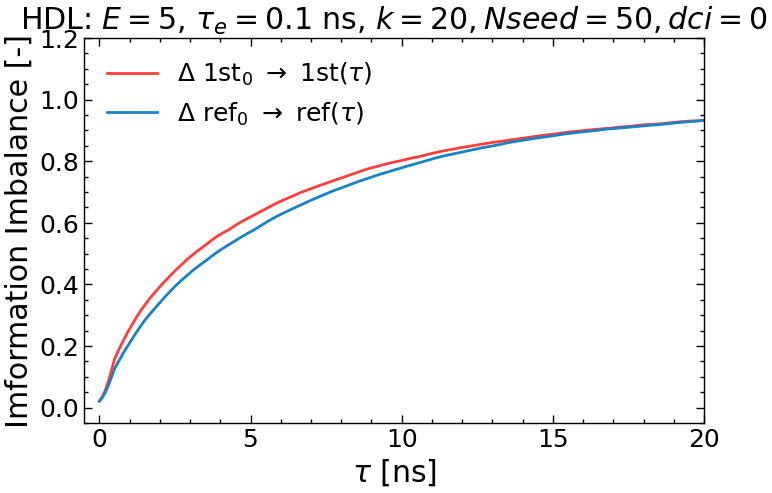

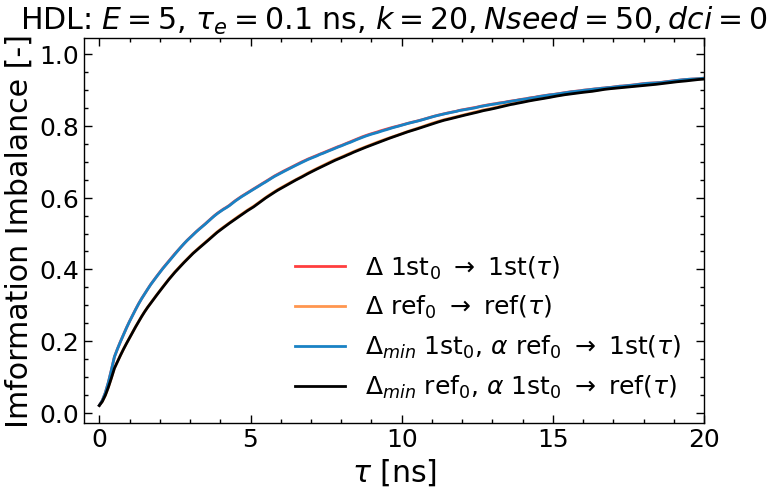

$\mathrm{\boldsymbol{\mu}}_{ref}$ $\rightarrow$ $\mathrm{\boldsymbol{\mu}}_{1st}$ 0.2029018530565056 9.3
$\mathrm{\boldsymbol{\mu}}_{1st}$ $\rightarrow$ $\mathrm{\boldsymbol{\mu}}_{ref}$ 0.3168740674767523 5.1000000000000005
(495,) (495,) (495,)


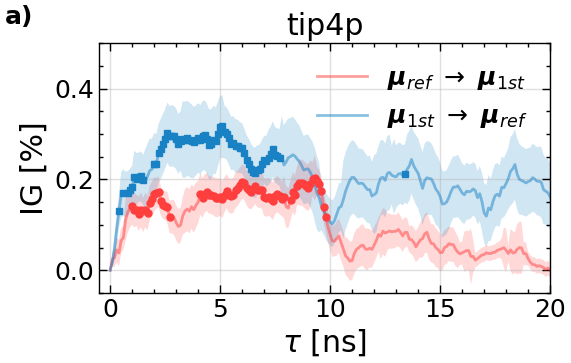

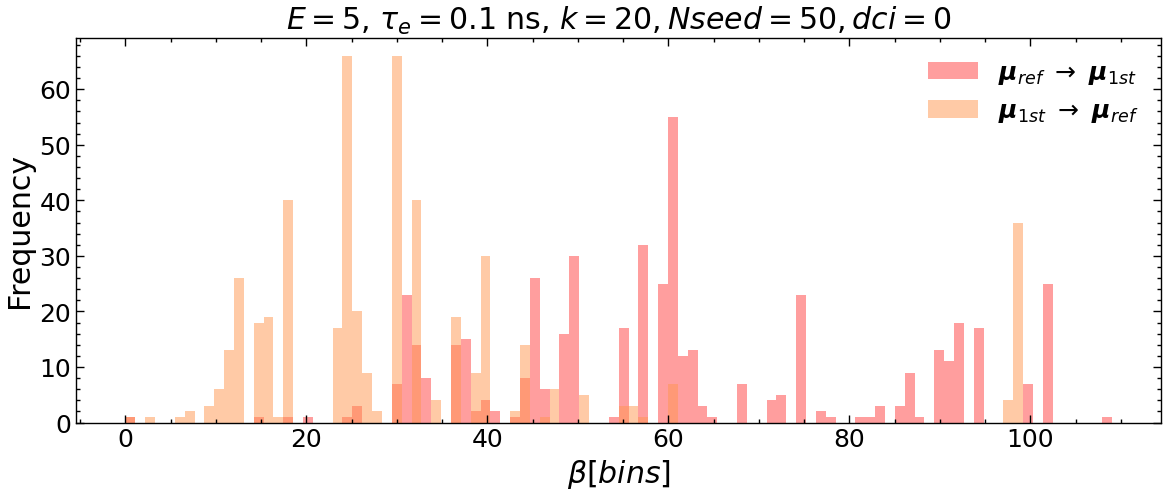

In [7]:
info_imbalances_X_to_Y = info_imbalances_center_to_1st
info_imbalances_Y_to_X = info_imbalances_1st_to_center
label_IG_X_to_Y = "$\\mathrm{\\boldsymbol{\\mu}}_{ref}$ $\\rightarrow$ $\\mathrm{\\boldsymbol{\\mu}}_{1st}$"
label_IG_Y_to_X = "$\\mathrm{\\boldsymbol{\\mu}}_{1st}$ $\\rightarrow$ $\\mathrm{\\boldsymbol{\\mu}}_{ref}$"
label_IB_Y0_to_Y = "$\\Delta$ 1st$_0$ $\\rightarrow$ 1st($\\tau$)"
label_IB_Y0X0_Y = "$\\Delta_{min }$ 1st$_0$, $\\alpha$ ref$_0$ $\\rightarrow$ 1st($\\tau$)"
label_IB_X0_to_X = "$\\Delta$ ref$_0$ $\\rightarrow$ ref($\\tau$)"
label_IB_X0Y0_X = "$\\Delta_{min }$ ref$_0$, $\\alpha$ 1st$_0$ $\\rightarrow$ ref($\\tau$)"


make_plot(info_imbalances_X_to_Y,
          info_imbalances_Y_to_X,
          label_IG_X_to_Y,
          label_IG_Y_to_X,
          label_IB_Y0_to_Y,
          label_IB_Y0X0_Y,
          label_IB_X0_to_X,
          label_IB_X0Y0_X,
          nseed = len(seeds),
          name_tpl = f"dipoleref_dipole1st_178K_2000B_8mcs_E{E}_k{k}_dci{dci}",
          xlim = 20,
          label = 'a)',
          )

Check ttest 


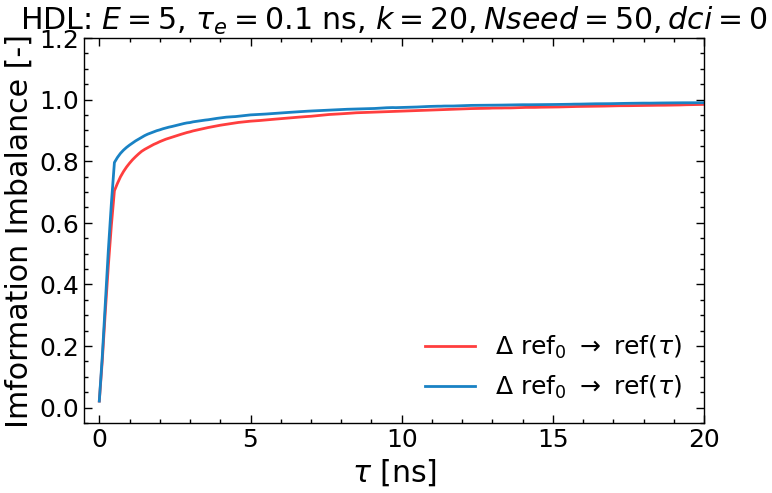

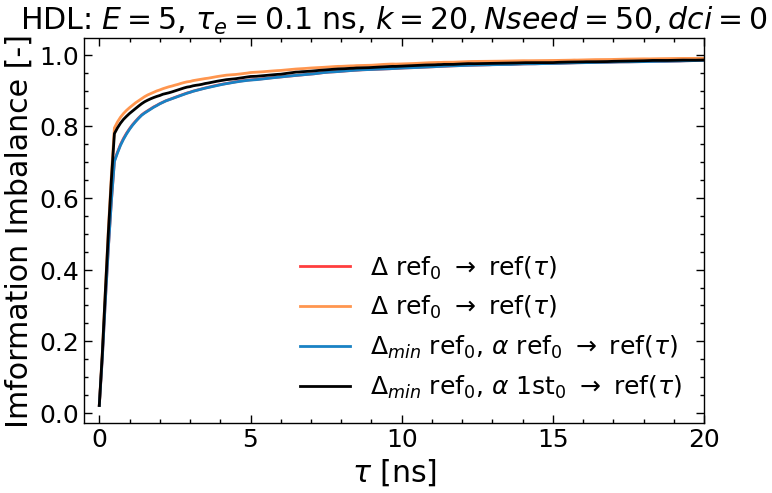

d$^*_{ref}$ $\rightarrow$ d$^*_{1st}$ 0.3133710338648339 0.6000000000000001
d$^*_{1st}$ $\rightarrow$ d$^*_{ref}$ 2.0293705015982213 0.6000000000000001
(495,) (495,) (495,)


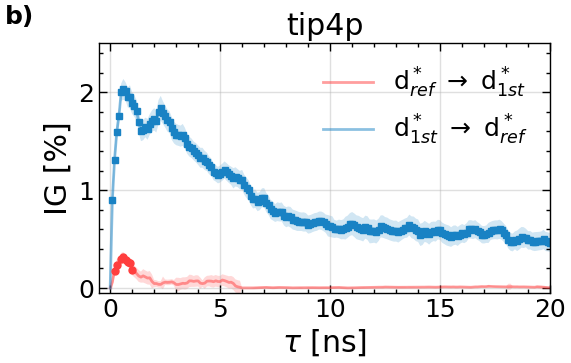

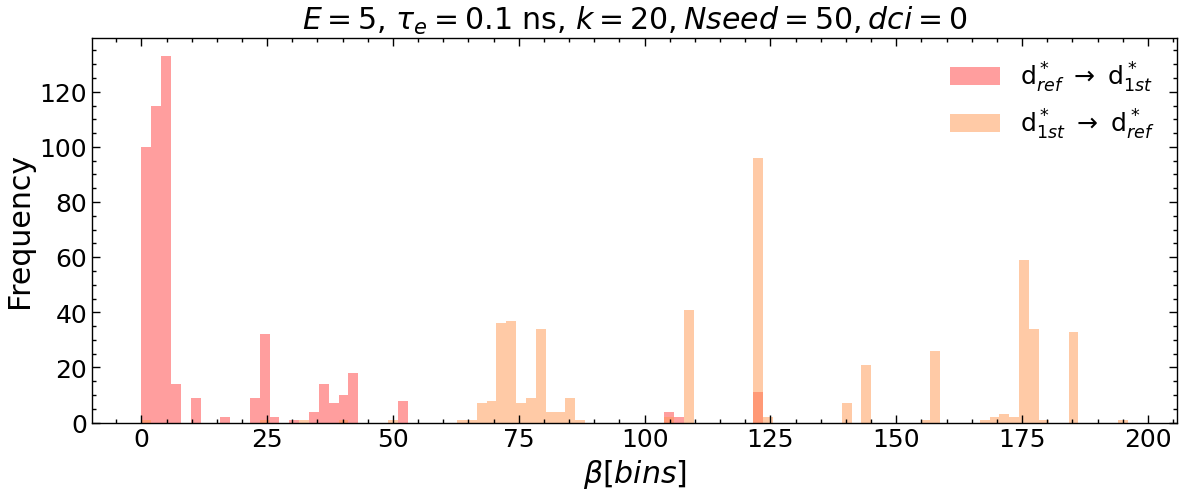

In [8]:
info_imbalances_X_to_Y = info_imbalances_centerd_to_1std
info_imbalances_Y_to_X = info_imbalances_1std_to_centerd
label_IG_X_to_Y = "d$^*_{ref}$ $\\rightarrow$ d$^*_{1st}$"
label_IG_Y_to_X = "d$^*_{1st}$ $\\rightarrow$ d$^*_{ref}$"
label_IB_Y0_to_Y = "$\\Delta$ ref$_0$ $\\rightarrow$ ref($\\tau$)"
label_IB_Y0X0_Y = "$\\Delta_{min }$ ref$_0$, $\\alpha$ ref$_0$ $\\rightarrow$ ref($\\tau$)"
label_IB_X0_to_X = "$\\Delta$ ref$_0$ $\\rightarrow$ ref($\\tau$)"
label_IB_X0Y0_X = "$\\Delta_{min }$ ref$_0$, $\\alpha$ 1st$_0$ $\\rightarrow$ ref($\\tau$)"


make_plot(info_imbalances_X_to_Y,
          info_imbalances_Y_to_X,
          label_IG_X_to_Y,
          label_IG_Y_to_X,
          label_IB_Y0_to_Y,
          label_IB_Y0X0_Y,
          label_IB_X0_to_X,
          label_IB_X0Y0_X,
          nseed = len(seeds),
          name_tpl = f"distanceref_distance1st_178K_200B_8mcs_E{E}_k{k}_dci{dci}",
          xlim = 20,
          ylim = 2.5,
          label = 'b)', 
          )

Check ttest 


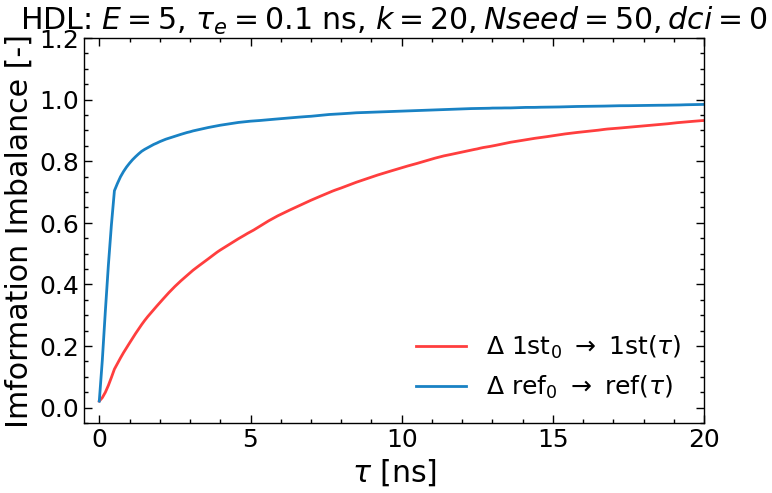

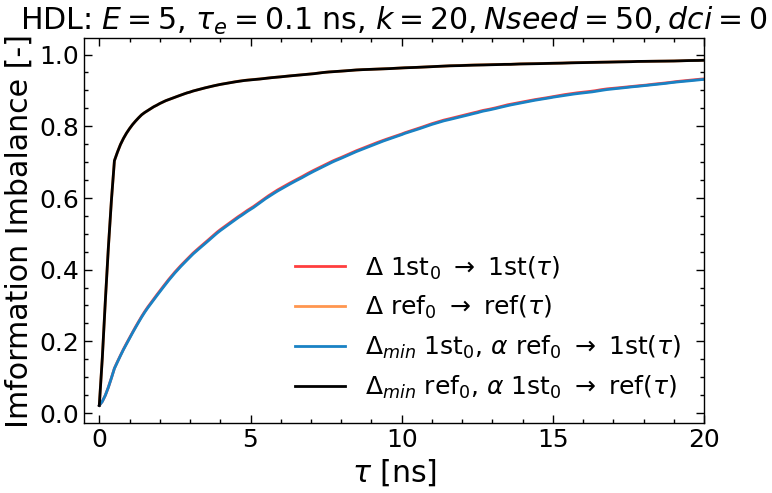

d$^*_{1st}$ $\rightarrow$ $\mathrm{\boldsymbol{\mu}}_{ref}$ 0.7073832215515263 1.9000000000000001
$\mathrm{\boldsymbol{\mu}}_{ref}$ $\rightarrow$ d$^*_{1st}$ 0.12403624577293573 14.100000000000001
(495,) (495,) (495,)


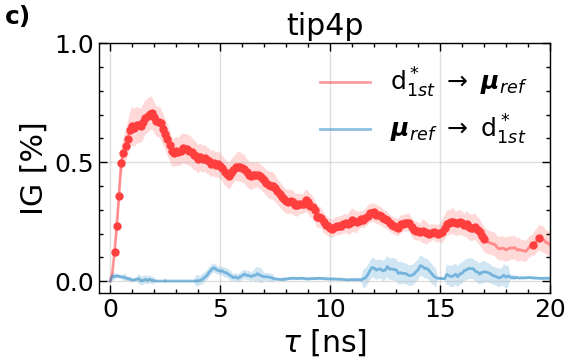

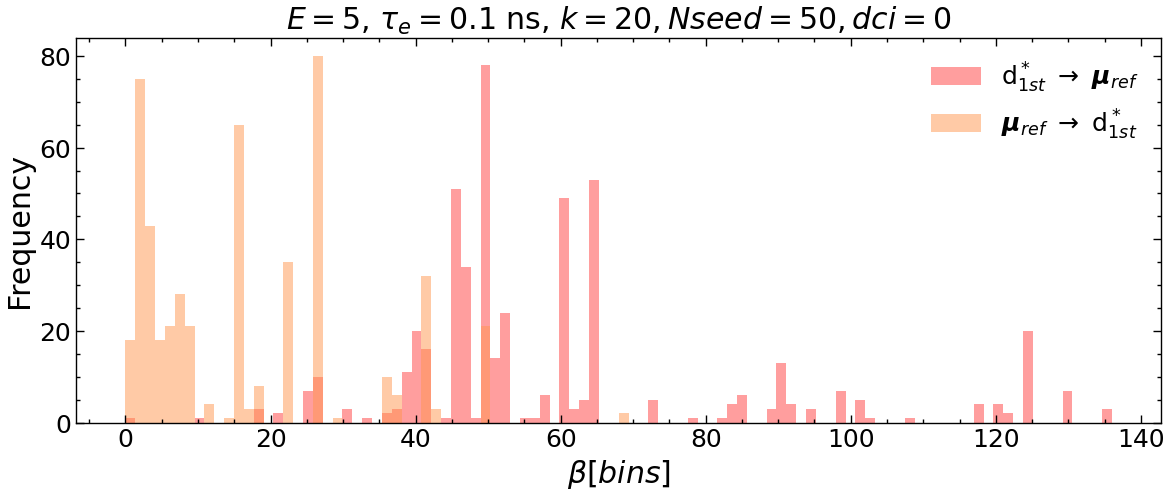

In [9]:
info_imbalances_X_to_Y = info_imbalances_1std_to_centerdipole
info_imbalances_Y_to_X = info_imbalances_centerdipole_to_1std
label_IG_X_to_Y = "d$^*_{1st}$ $\\rightarrow$ $\\mathrm{\\boldsymbol{\\mu}}_{ref}$"
label_IG_Y_to_X = "$\\mathrm{\\boldsymbol{\\mu}}_{ref}$ $\\rightarrow$ d$^*_{1st}$"
label_IB_Y0_to_Y = "$\\Delta$ 1st$_0$ $\\rightarrow$ 1st($\\tau$)"
label_IB_Y0X0_Y = "$\\Delta_{min }$ 1st$_0$, $\\alpha$ ref$_0$ $\\rightarrow$ 1st($\\tau$)"
label_IB_X0_to_X = "$\\Delta$ ref$_0$ $\\rightarrow$ ref($\\tau$)"
label_IB_X0Y0_X = "$\\Delta_{min }$ ref$_0$, $\\alpha$ 1st$_0$ $\\rightarrow$ ref($\\tau$)"


make_plot(info_imbalances_X_to_Y,
          info_imbalances_Y_to_X,
          label_IG_X_to_Y,
          label_IG_Y_to_X,
          label_IB_Y0_to_Y,
          label_IB_Y0X0_Y,
          label_IB_X0_to_X,
          label_IB_X0Y0_X,
          nseed = len(seeds),
          name_tpl = f"distance1st_dipoleref_178K_200B_8mcs_E{E}_k{k}_dci{dci}",
          xlim = 20,
          ylim = 1,

          label='c)',
          )